# Guidelines for use of MAST_tools

Notebook demostrating the utilities in MAST_tools modules.

Author: Rodrigo Ordonez-Hurtado (rodrigo.ordonez.hurtado@ibm.com)

In [1]:
import sys
sys.path.insert(1, '../scripts')

import zarr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from MAST_tools.store_utils import MASTStorageManager
from MAST_tools.signal_utils import MASTSignalManager
from MAST_tools.plotting_utils import MASTPlottingManager


# Store utilities

## Creation of store manager

In [3]:
store_manager = MASTStorageManager()

### List all available shot IDs

In [ ]:
if False:
    all_shots_ids = store_manager.list_all_shots(
        level=2,
        test_data=False,
        local=False,
        via_parquet=False
    )
    
    pprint(all_shots_ids)


### List all sources

In [ ]:
if False:
    all_sources = store_manager.get_all_sources(
        shot_ids=[30421],  # all_shots_ids[0]
        level=2,
        test_data=False,
        local=False,
        via_parquet=False
    )

    try:
        pprint(all_sources)
        print("\n\nall_sources.keys:\n")
        pprint(all_sources.keys())
    except Exception as e:
        print(e)
        

### List all signals

In [ ]:
if False:
    all_signals = store_manager.get_all_signals(
        shot_ids=[30421],  # Use None for the entire dataset.
        level=2,
        test_data=False,
        local=False,
        via_parquet=False
    )

    pprint(all_signals)


### Make group directly from shot_id

In [ ]:
if False:
    store_ = store_manager.make_shot_store(
        shot_info={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False}
    )
    group_from_store = store_manager.make_shot_group(data_origin=store_)
    print(f"group_from_store.tree() (group from store): {group_from_store.tree()}\n")


### Make group from existing store object

In [ ]:
if False:
    group_from_shot_info = store_manager.make_shot_group(
        data_origin={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False}
    )
    print(f"group_from_shot_info.tree() (group from shot info): {group_from_shot_info.tree()}\n")
    
    if False:
        gg = group_from_shot_info.metadata.to_dict()
        pprint(gg["consolidated_metadata"]["metadata"])

### Check signal availability

In [ ]:
if False:
    
    # REMARK:
    # Signal avaialbility file should be stored under the fairmast-data-preprocessing/metadata/ directory.
    # One of such files is saved as "data_level2_signal_availability.csv" at fairmast-data-preprocessing/metadata/2025-04-17
    
    # signal_availability_file = "../../metadata/2025-04-17/data_level2_signal_availability.csv"
    signal_availability_file = "../metadata/2025-04-17/data_level2_signal_availability.csv"
    
    dict_target_signals = {
        "thomson_scattering": ["n_e"],
        "spectrometer_visible": ["filter_spectrometer_bes_voltage"],
        "summary": ["power_nbi", "ip"],
    }

    print("\nSignals to be checked for simultaneous availability across all shots:")
    pprint(dict_target_signals)
        
    filtered_ids = store_manager.list_shots_by_signal_availability(
        availability_data_filepath=signal_availability_file,
        required_signals=dict_target_signals
    )

    print(f"\nfiltered_ids ({len(filtered_ids)} shots):")
    pprint(filtered_ids)

# Signal utilities

### Creation of signal manager

In [7]:
signal_manager = MASTSignalManager()

### Get signal values from existing store 

In [4]:
if False:
    # First create a store from shot info
    store_from_shot_info = store_manager.make_shot_store(
        shot_info={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False}
    )
    
    # Then get signal values from that store
    signal_values = signal_manager.get_signal_values(
        data_origin=store_from_shot_info,
        source_name="magnetics",
        signal_name="flux_loop_flux"
    )

    print(f"Signal values:\n")
    pprint(signal_values)
    

### Get signal values from shot info

In [29]:
if False:
    # Get signal values directly from shot info
    
    shot_info = {"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False}
    source_name = "thomson_scattering"  # "magnetics",
    signal_name = "n_e"  # "flux_loop_flux"
    
    signal_values = signal_manager.get_signal_values(
        data_origin=shot_info,
        source_name=source_name,
        signal_name=signal_name
    )

    print(f"Signal values:\n")
    pprint(signal_values)
    
    if False:
        np.save(f"{source_name}__{signal_name}__{shot_info['shot_id']}", signal_values)
    

# Plotting utilities

## Creation of managers

In [20]:
plotting_manager = MASTPlottingManager()
signal_manager = MASTSignalManager()

## Settings for tests

In [21]:
%matplotlib notebook
# %matplotlib inline

# Create a group to plot from
group_from_shot_info = store_manager.make_shot_group(
    data_origin={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False}
)

available_sources = list(group_from_shot_info.keys())
target_source = 'summary'  # available_sources[0]

available_signals = list(group_from_shot_info[target_source].keys())

# Create source profiles from target store
source_profiles = signal_manager.get_source_profiles(
    data_origin=group_from_shot_info.store,
    source_name=target_source
)

source_profiles


<xarray.Dataset> Size: 163kB
Dimensions:              (time: 2906)
Coordinates:
  * time                 (time) float64 23kB -0.0612 -0.06095 ... 0.6648 0.665
Data variables:
    greenwald_density    (time) float64 23kB ...
    ip                   (time) float64 23kB ...
    line_average_n_e     (time) float64 23kB ...
    neutron_rates_total  (time) float64 23kB ...
    power_nbi            (time) float64 23kB ...
    power_radiated       (time) float64 23kB ...
Attributes:
    description:  
    imas:         summary
    label:        Plasma Current
    name:         summary
    uda_name:     AMC_PLASMA CURRENT
    units:        A

## Plotting examples

### Plot single profile (from DataArray)

In [ ]:
if False:
    
    # Select target signal from available signals
    target_signal = available_signals[0]
    
    # Plot signal
    plotting_manager.plot_1d_profiles(
        profiles=source_profiles[target_signal],
        fig_size=[8, 4]
    )


### Plot group of profiles (from Dataset)

In [ ]:
if False:
    plotting_manager.plot_1d_profiles(
        profiles=source_profiles,
        fig_size=[8, 8]
    )

### Plot target signal from store

In [ ]:
if False:
    plotting_manager.plot_signal(
        data_origin=group_from_shot_info.store,
        source_name="magnetics",
        signal_name="ip",
        fig_size=[8, 4]
    )

### Plot target signal from shot info

C:\Users\I85464754\OneDrive - IBM\01 Current Work\01 Fusion and Heliophysics\02 Repos\02 GitLab\fairmast-data-preprocessing\notebooks\../scripts\MAST_tools\plotting_utils.py:102: UserWarning: WARNING: This method misbehaves if not run in a notebook with `%matplotlib notebook` header.
  warnings.warn(


<IPython.core.display.Javascript object>


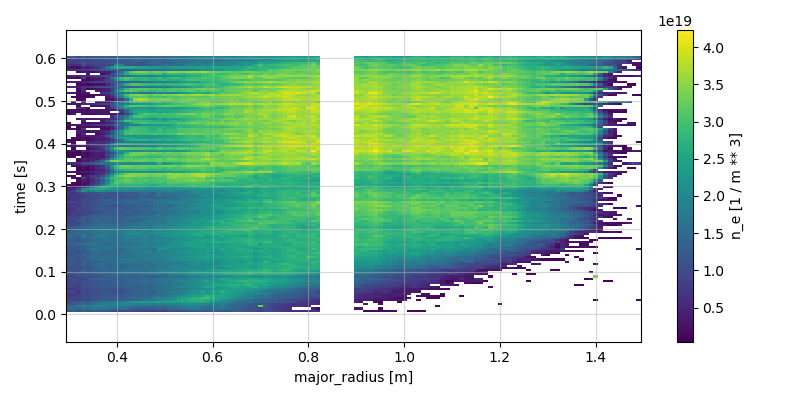

In [22]:
if True:
    plotting_manager.plot_signal(
        data_origin={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False},
        source_name="thomson_scattering",  # "magnetics",
        signal_name="n_e",  # "ip",
        fig_size=[8, 4]
    )

### Plot target group from store

In [ ]:
if False:
    plotting_manager.plot_group(
        data_origin=group_from_shot_info.store,
        source_name="magnetics",
#         fig_size=[8, 12]
    )

### Plot target group from shot info

In [ ]:
if False:
    plotting_manager.plot_group(
        data_origin={"shot_id": 30421, "level": 2, "test_data": False, "local": False, "via_parquet": False},
        source_name="magnetics",
#         fig_size=[8, 4]
    )

### Plot specific groups

In [ ]:
if False:
    plotting_manager.plot_plasma_current(data_origin=group_from_shot_info.store)
    

In [ ]:
if False:
    plotting_manager.plot_power_nbi(data_origin=group_from_shot_info.store)
    

In [ ]:
if False:
    plotting_manager.plot_magnetics(data_origin=group_from_shot_info.store)
    

In [ ]:
if False:
    plotting_manager.plot_spectrometer(data_origin=group_from_shot_info.store)
    

In [ ]:
if False:
    plotting_manager.plot_charge_exchange(data_origin=group_from_shot_info.store)
    

In [ ]:
if False:
    plotting_manager.plot_thomson_scattering(data_origin=group_from_shot_info.store)
    

In [ ]:
raise SystemError

# Not yet implemented

Group 'cameras' was not found in consolidated metadata.
Reason? It's only available for level 1 data, not yet included in level 2 data.

Access to camera data requires availability of profiles['camera_a'] and profiles['camera_b'].
